In [1]:
print("Hello World")

Hello World


In [4]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits 
from astropy import wcs
from astropy.wcs  import WCS
from astropy.io import ascii
import astropy.coordinates as coord 
import astropy.units as u 
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from reproject import reproject_from_healpix, reproject_to_healpix
from matplotlib.colors import LogNorm

In [3]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [4]:
from reproject import reproject_interp
from reproject import reproject_adaptive 
from reproject import reproject_exact
from astropy.visualization.wcsaxes.frame import EllipticalFrame

In [5]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/frequency_cubes/dragons_freqK_gal_conv_i.hpx.fits'
freqKidat = fits.getdata(fn) 
freqKiheader = fits.getheader(fn)

In [6]:
freqKiheader

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
BUNIT   = 'K       '        

In [7]:
import healpy as hp

In [8]:
freqKiheader


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
BUNIT   = 'K       '        

In [9]:
freqKidat.shape

(680, 196608)

In [10]:
fn =  '/srv/data/dragons/dragons-canfar-Nov2025/masks/dragons_bright_src_mask_gal.hpx.fits'
brSrcdat = fits.getdata(fn)
brSrchdr = fits.getheader(fn)
brSrchdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-17'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
CUNIT2  = 'MHz     '        

In [11]:
out

NameError: name 'out' is not defined

In [12]:
naxis2, naxis1 = out.get_array().shape
naxis1, naxis2

NameError: name 'out' is not defined

In [13]:
w = wcs.WCS(naxis=2)
w.wcs.ctype = ( 'GLON-MOL', 'GLAT-MOL')
w.wcs.crval = (0 ,0)
w.wcs.crpix = ( naxis1 / 2, naxis2 / 2)
w.wcs.cdelt = ( -360.0 / naxis1, 180 / naxis2 )
w

NameError: name 'naxis1' is not defined

In [14]:
data_mollweide, footprint = reproject_from_healpix((freqKidat[261], 'G'),
                                                   w, shape_out=[500, 1000],
                      nested=False)
data_mollweide

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(500, 1000))

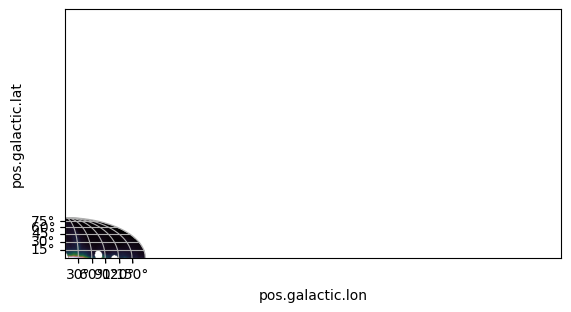

In [15]:
fig = plt.figure()
ax = fig.add_subplot(projection=w)
ax.imshow(data_mollweide, cmap = 'cubehelix')
ax.grid()

In [16]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/frequency_cubes/dragons_freqK_gal_conv_q.hpx.fits'
freqKqdat = fits.getdata(fn) 
freqKqhdr = fits.getheader(fn)

DRAGONS Stokes Frequency plots
==

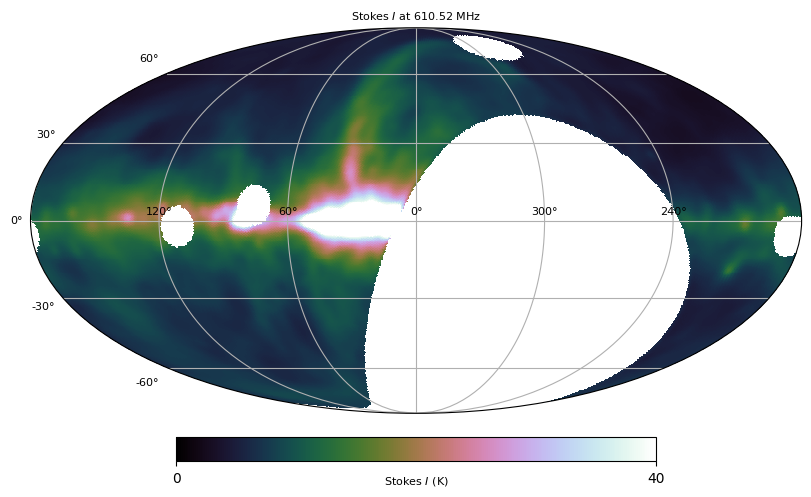

In [92]:
out = projview(freqKidat[261], 
         title = r'Stokes $\mathit{I}$ at 610.52 MHz',
         min = 0, 
         max = 40, 
         unit = r'Stokes $\mathit{I}$ (K)', 
         cmap = "cubehelix",
         graticule=True, 
         graticule_labels=True,
         cb_orientation="horizontal", 
         # flip='astro',
         fontsize={
            "title":8,
             "xtick_label":8,
             "ytick_label":8, 
             "cbar_label":8
         },
         badcolor = 'white',
         projection_type='mollweide'
        )

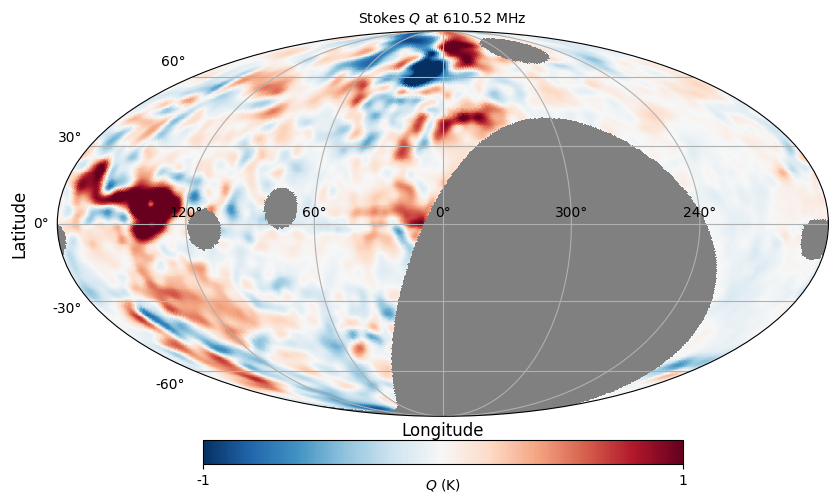

In [16]:
projview(
    freqKqdat[261],
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    xlabel="Longitude", 
    ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'RdBu_r',
    min = -1, 
    max = 1,
    title = r'Stokes $\mathit{Q}$ at 610.52 MHz', 
    unit = r'$\mathit{Q}$ (K)',
    # norm = 'symlog2',
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [17]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/frequency_cubes/dragons_freqK_gal_conv_u.hpx.fits'
freqKudat = fits.getdata(fn) 
freqKuhdr = fits.getheader(fn)

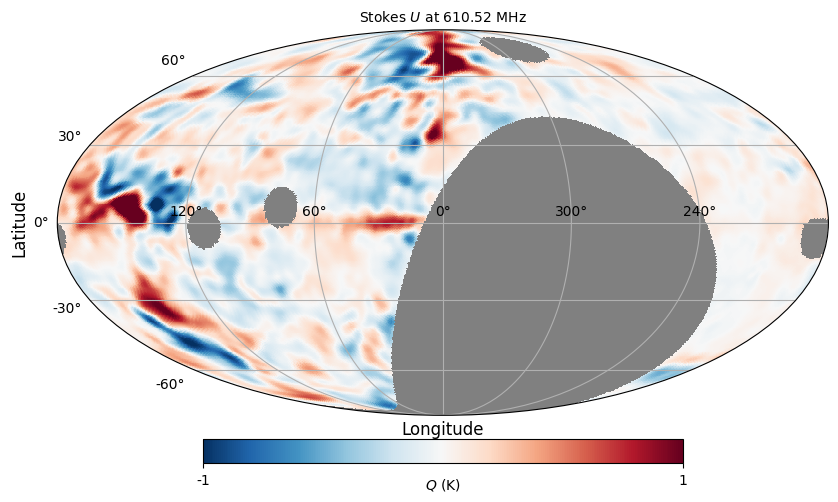

In [18]:
projview(
    freqKudat[261],
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    xlabel="Longitude", 
    ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'RdBu_r',
    min = -1, 
    max = 1,
    title = r'Stokes $\mathit{U}$ at 610.52 MHz', 
    unit = r'$\mathit{Q}$ (K)',
    # norm = 'symlog2',
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

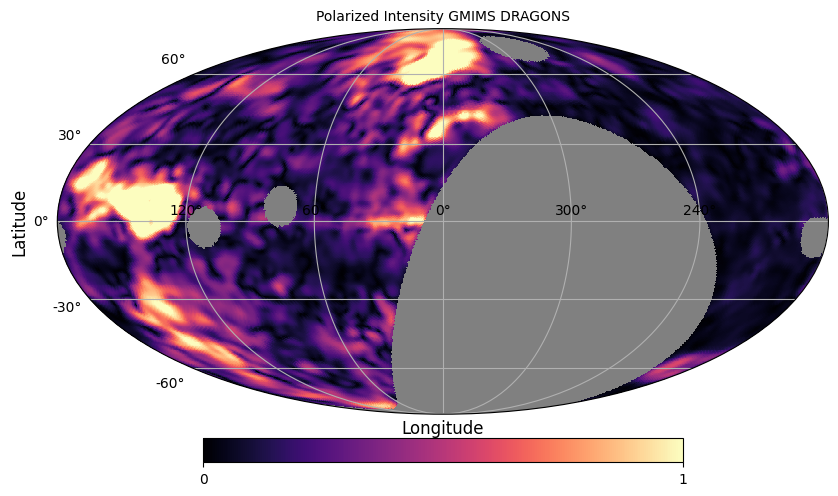

In [19]:
PolInt = np.sqrt(freqKqdat[261]**2 + freqKudat[261]**2)
projview(
    PolInt,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    xlabel="Longitude", 
    ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'magma',
    min = 0, 
    max = 1,
    title = r'Polarized Intensity GMIMS DRAGONS', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [20]:
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [21]:
Polangle = 0.5 * np.arctan2(freqKudat[261], freqKqdat[261])
degPolangle = np.degrees(Polangle)

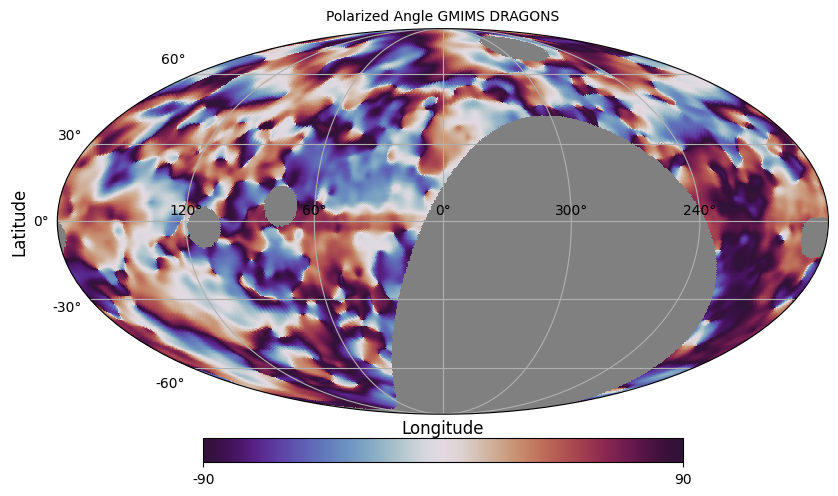

In [22]:
projview(
    degPolangle,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    xlabel="Longitude", 
    ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'twilight_shifted',
    min = -90, 
    max = 90,
    title = r'Polarized Angle GMIMS DRAGONS', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [23]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_FDF_lambda0Sq_gal.hpx.fits'
FDFCCdata = fits.getdata(fn)
FDFCCheader = fits.getheader(fn)

In [24]:
FDFCCheader

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'm^2     '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

Faraday Depth Moment Maps and # of Faraday Depth Peaks Above 8 sigma
==

In [17]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn) 

In [18]:
#lets do the faraday depth momment maps, yipee 
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_M0_gal.hpx.fits'
fdm0dat = fits.getdata(fn) 
fdm0hdr = fits.getheader(fn)

In [19]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_M1_gal.hpx.fits'
fdm1dat = fits.getdata(fn) 
fdm1hdr = fits.getheader(fn)

In [20]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_m2_gal.hpx.fits'
fdm2dat = fits.getdata(fn) 
fdm2hdr = fits.getheader(fn)

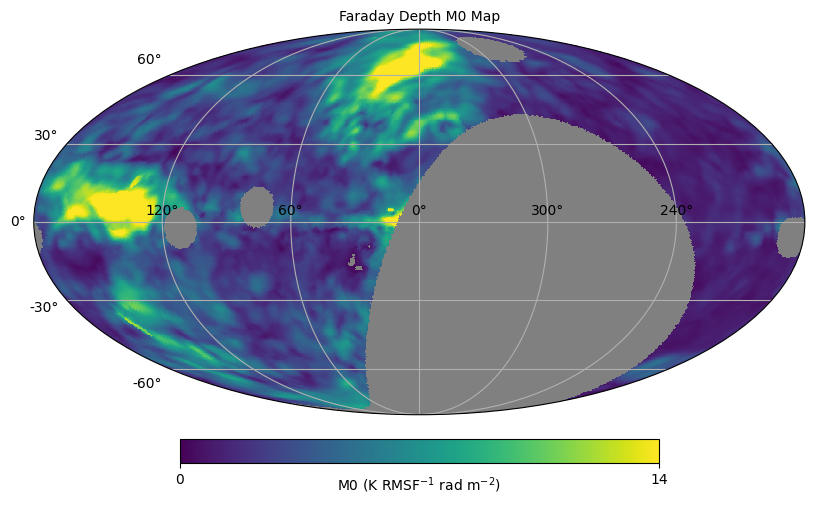

In [21]:
projview(
    fdm0dat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    #cmap = 'twilight_shifted',
    min = 0, 
    max = 14,
    unit = r'M0 (K RMSF$^{-1}$ rad m$^{-2}$)',
    title = r'Faraday Depth M0 Map', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

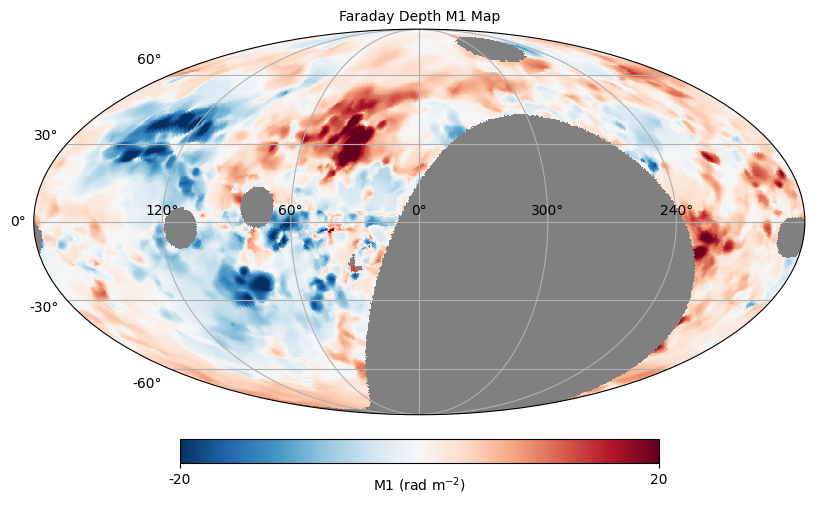

In [22]:
projview(
    fdm1dat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'RdBu_r',
    min = -20, 
    max = 20,
    unit = r'M1 (rad m$^{-2}$)',
    title = r'Faraday Depth M1 Map', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

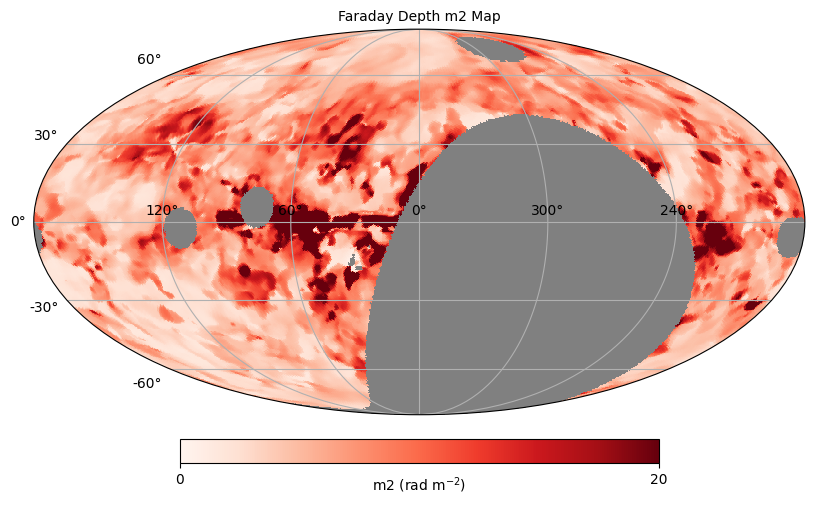

In [23]:
projview(
    fdm2dat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = 'Reds',
    min = 0, 
    max = 20,
    unit = r'm2 (rad m$^{-2}$)',
    title = r'Faraday Depth m2 Map', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [32]:
fdm2hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'rad/m^2 '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [24]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

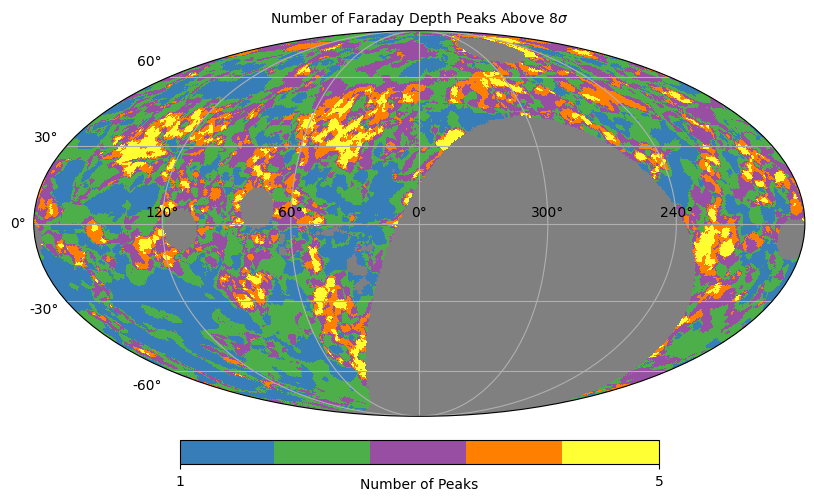

In [25]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [31]:
#want to see what the LBS faraday depth looks like 
fn = '/srv/data/gmims/gmims-lbs/parkes_pi_gal.DR2.HPX.fits' 
data = fits.getdata(fn) 
hdr  = fits. getheader(fn) 
hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               786432                                                  
NAXIS2  =                  388                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRVAL3  =           286250000. / reference pixel value                          
CRPIX3  =                   1. / reference value                                
CDELT3  =             500000.  / Hz/pixel                                       
CTYPE3  = 'FREQ    '           / z-axis                                         
CUNIT3  = 'Hz      '                                                            
BMAJ    =                 1.

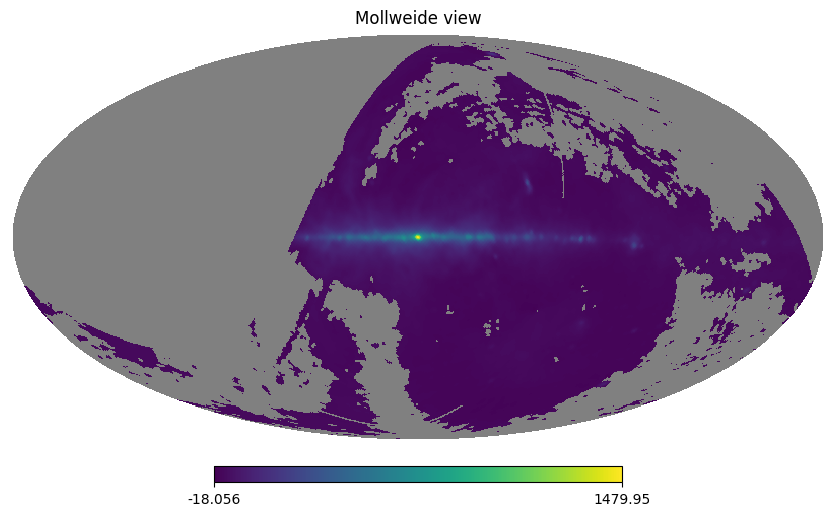

In [40]:
hp.mollview(data[210])

reprojection to plate caree
==

In [35]:
ref_hdr = fits.getheader('/srv/data/dragons/dragons-canfar-Nov2025/frequency_cubes/dragons_freqK_gal_conv_q.car.fits')

In [36]:
ref_hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT1  =                 -0.5                                                  
CRPIX1  =                360.5                                                  
CRVAL1  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

In [37]:
w_ref = wcs.WCS(ref_hdr).celestial
w_ref

a floating-point value was expected. [astropy.wcs.wcs]


WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CAR' 'GLAT-CAR' 
CRVAL : 0.0 0.0 
CRPIX : 360.5 180.5 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.5 0.5 
NAXIS : 720  360

In [38]:
data_car, footprint = reproject_interp( (data_mollweide, w), w_ref,
                                       shape_out=[360,720])

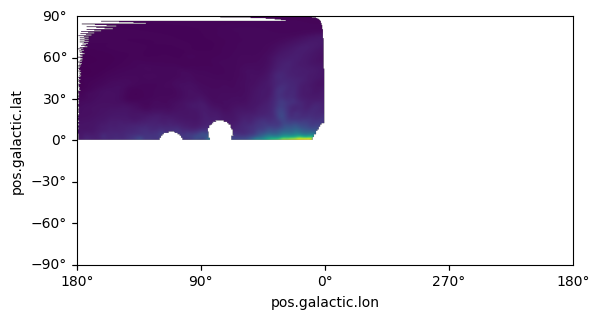

In [39]:
fig = plt.figure()
ax = fig.add_subplot(projection=w_ref)
ax.imshow(data_car)

DRAGONS-LBS 408 MHz Q and U, pearson correlation coefficient 0.63
==

In [27]:
fn = '/srv/data/gmims/gmims-lbs/parkes_q.gal.DR2.HPX.fits'
lbsqdat = fits.getdata(fn)
lbsqhdr = fits.getheader(fn)

In [69]:
lbsqhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               786432                                                  
NAXIS2  =                  388                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRVAL3  =           286250000. / reference pixel value                          
CRPIX3  =                   1. / reference value                                
CDELT3  =             500000.  / Hz/pixel                                       
CTYPE3  = 'FREQ    '           / z-axis                                         
CUNIT3  = 'Hz      '                                                            
BMAJ    =                 1.

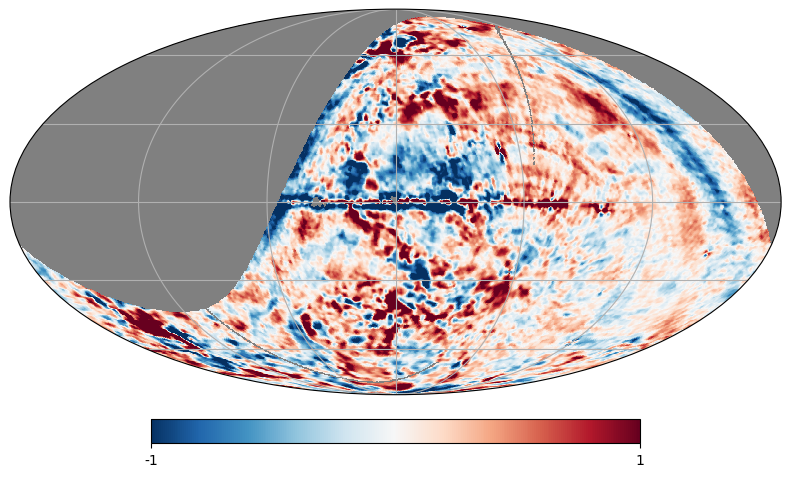

In [28]:
projview(lbsqdat[210], 
         projection_type = "mollweide", 
         coord = 'C',
         # rot = (180, 180, 0),
         flip = 'astro',
         cmap = 'RdBu_r',
         min = -1,
         max = 1,
         graticule = True
         
        )

In [71]:
#freqKqdat[261]
#getting q at 408 MHz for each dataset
#they overlap declination -20 to 20 
dragonsq = freqKqdat[57] #216'
lbsq = lbsqdat[244] #81' 

In [72]:
freqKqhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
BUNIT   = 'K       '        

In [73]:
lbsqhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               786432                                                  
NAXIS2  =                  388                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRVAL3  =           286250000. / reference pixel value                          
CRPIX3  =                   1. / reference value                                
CDELT3  =             500000.  / Hz/pixel                                       
CTYPE3  = 'FREQ    '           / z-axis                                         
CUNIT3  = 'Hz      '                                                            
BMAJ    =                 1.

In [74]:
np.nanmax(x), np.nanmax(y)

(np.float64(2.0148081433390495), np.float64(2.9005562748739075))

In [75]:
NSIDE = 64 
UNSEEN_THRESH = -1E29


In [80]:
# Rotate DRAGONS Q and U from Equatorial -> Galactic together
r = hp.Rotator(coord=['G', 'C'])

dragonsq_64 = hp.ud_grade(freqKqdat[57], nside_out=NSIDE)
dragonsu_64 = hp.ud_grade(freqKudat[57], nside_out=NSIDE)  # your U equivalent
dummy_i = np.zeros_like(dragonsq_64)
# This rotates the vector field correctly, mixing Q and U by the parallactic angle
_, dragonsq_gal, dragonsu_gal = r.rotate_map_alms(
    [dummy_i, dragonsq_64, dragonsu_64]
)

In [81]:
NSIDE = 64
UNSEEN_THRESH = -1e29

# Skip smoothing for now to isolate the problem
dragonsq_gal = hp.ud_grade(dragonsq, nside_out=NSIDE)
lbs_64     = hp.ud_grade(lbsq,     nside_out=NSIDE)

npix = hp.nside2npix(NSIDE)
l, b = hp.pix2ang(NSIDE, np.arange(npix), lonlat=True)



In [82]:
mask = (np.abs(b) > 10) & \
       (dragonsq_gal > UNSEEN_THRESH) & \
       (lbs_64 > UNSEEN_THRESH)

x = dragonsq_gal[mask]
y = lbs_64[mask]

print(f"Points: {mask.sum():,}")
print(f"Pearson r = {np.corrcoef(x,y)[0,1]:.3f}")

Points: 14,295
Pearson r = 0.625


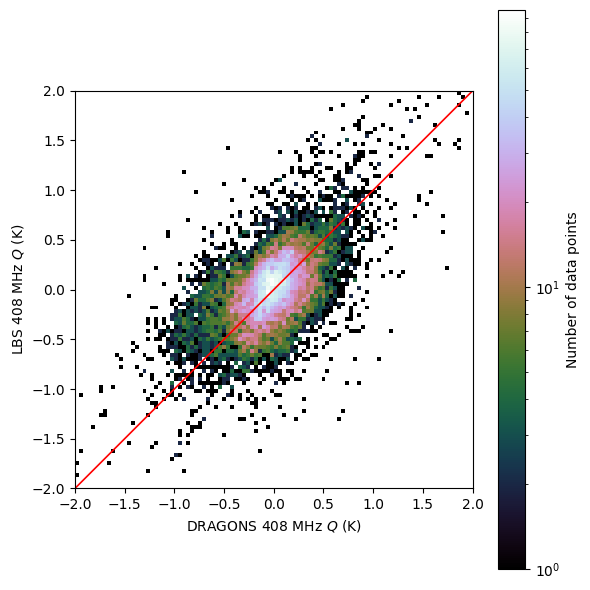

In [83]:
fig, ax = plt.subplots(figsize=(6,6))
counts, xedges, yedges, img = ax.hist2d(
    x, y, bins=100, norm=LogNorm(), cmap='cubehelix', range=[[-2,2],[-2,2]])
plt.colorbar(img, ax=ax, label='Number of data points')
ax.plot([-2,2], [-2,2], 'r-', lw=1.2)
ax.set_xlabel('DRAGONS 408 MHz $Q$ (K)')
ax.set_ylabel('LBS 408 MHz $Q$ (K)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [84]:
fn = '/srv/data/gmims/gmims-lbs/parkes_u.gal.DR2.HPX.fits'
lbsudat = fits.getdata(fn)
lbsuhdr = fits.getheader(fn) 

In [85]:
lbsuhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               786432                                                  
NAXIS2  =                  388                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CRVAL3  =           286250000. / reference pixel value                          
CRPIX3  =                   1. / reference value                                
CDELT3  =             500000.  / Hz/pixel                                       
CTYPE3  = 'FREQ    '           / z-axis                                         
CUNIT3  = 'Hz      '                                                            
BMAJ    =                 1.

In [86]:
freqKuhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
BUNIT   = 'K       '        

In [87]:
freqKqhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  680                                                  
DATE    = '2025-11-18'                                                          
INSTRUME= 'DRAO-15 '                                                            
EPOCH   = '2000    '                                                            
CDELT2  =                  1.0                                                  
CRPIX2  =                    1                                                  
CRVAL2  =           350.520833                                                  
CTYPE2  = 'FREQ    '                                                            
BUNIT   = 'K       '        

In [88]:
lbsu = lbsudat[244]
dragonsu = freqKudat[57]

In [89]:
NSIDE = 64
UNSEEN_THRESH = -1e29

# Skip smoothing for now to isolate the problem
dragonsu_gal = hp.ud_grade(dragonsu, nside_out=NSIDE)
lbsu_64     = hp.ud_grade(lbsu,     nside_out=NSIDE)

npix = hp.nside2npix(NSIDE)
l, b = hp.pix2ang(NSIDE, np.arange(npix), lonlat=True)


In [90]:
mask = (np.abs(b) > 10) & \
       (dragonsu_gal > UNSEEN_THRESH) & \
       (lbsu_64 > UNSEEN_THRESH)

x = dragonsu_gal[mask]
y = -lbsu_64[mask]

print(f"Points: {mask.sum():,}")
print(f"Pearson r = {np.corrcoef(x,y)[0,1]:.3f}")

Points: 14,295
Pearson r = 0.622


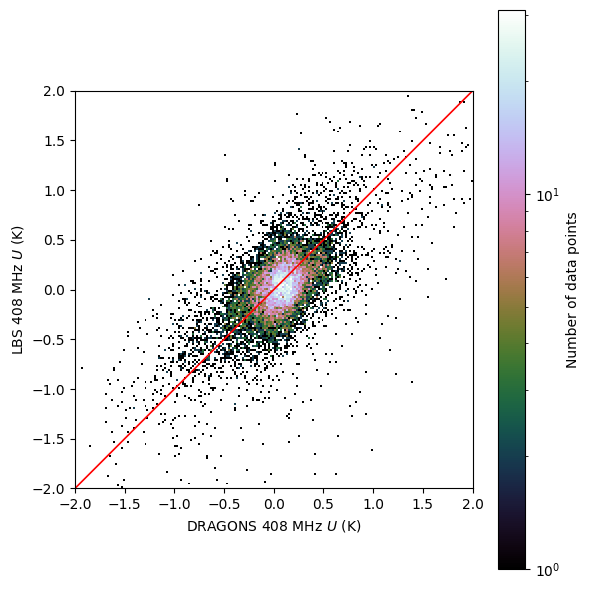

In [91]:
fig, ax = plt.subplots(figsize=(6,6))
counts, xedges, yedges, img = ax.hist2d(
    x, y, bins=200, norm=LogNorm(), cmap='cubehelix', range=[[-2,2],[-2,2]])
plt.colorbar(img, ax=ax, label='Number of data points')
ax.plot([-2,2], [-2,2], 'r-', lw=1.2)
ax.set_xlabel('DRAGONS 408 MHz $U$ (K)')
ax.set_ylabel('LBS 408 MHz $U$ (K)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [104]:
fn = '/srv/data/gmims/gmims-lbs/parkes_pi_gal.clean.fits' 
qgaldat = fits.getdata(fn) 
qgalhdr = fits.getheader(fn)

In [105]:
qgalhdr

SIMPLE  =                    T  /                                               
BITPIX  =                  -32  /                                               
NAXIS   =                    3  /                                               
NAXIS1  =                 1440  /                                               
NAXIS2  =                  720  /                                               
NAXIS3  =                  401  /                                               
EXTEND  =                    T  /                                               
BSCALE  =    1.00000000000E+00  /                                               
BZERO   =    0.00000000000E+00  /                                               
BLANK   =                   -1  /                                               
CRPIX1  =    7.20500000000E+02  /                                               
CDELT1  =   -2.50000000000E-01  /                                               
CRVAL1  =    0.00000000000E+